**Dataset:** `data/placement_predict_50k Dataset_final.csv` (50,000 students).

The preprocessed splits read below (`X_train_processed*.csv`, `X_test_processed*.csv`, `y_train.csv`, `y_test.csv`) were regenerated from this dataset with the same steps as `03_Final_preprocessing_Complete_Steps` (duplicates removed, stratified 80/20 split with `random_state=42`, median imputation, one-hot encoding, standard scaling). `CollegeTier` is ordinal-encoded (Tier3=0, Tier2=1, Tier1=2); in `X_*_processed.csv` `CGPA_Tier` is also encoded (Low=0, Mid=1, High=2), in `X_*_processed1.csv` it stays as Low/Mid/High because it is the target of the multinomial notebook.

# Multinomial Logistic Regression — CGPA Tier

## Objective
Develop a Logistic Regression classification model to predict **`CGPA_Tier`** and evaluate it using standard classification metrics.

### Data assumption
The data is already preprocessed:
- `X_train` = 80% preprocessed features
- `X_test` = 20% preprocessed features
- `y_train` = target for training
- `y_test` = target for testing

**No additional imputation, encoding, or scaling is performed here.**

### Required outputs
- `evaluate_classifier()` function
- Accuracy
- Precision
- Recall
- F1-score
- Confusion matrix
- Classification report
- Coefficient bar chart


## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_auc_score
)


## 2. Load Already-Preprocessed Data

In [2]:
# Change these paths to your actual files
X_TRAIN_PATH = "/Users/divyasaisomana/placement prediction system/data/X_train_processed1.csv"
X_TEST_PATH  = "/Users/divyasaisomana/placement prediction system/data/X_test_processed1.csv"
#Y_TRAIN_PATH = "/Users/divyasaisomana/placement prediction system/data/y_train_CGPA_Tier.csv"
#Y_TEST_PATH  = "/Users/divyasaisomana/placement prediction system/data/y_test_CGPA_Tier.csv"

X_train = pd.read_csv(X_TRAIN_PATH)
X_test = pd.read_csv(X_TEST_PATH)

y_train = X_train['CGPA_Tier']
y_test = X_test['CGPA_Tier']
X_train1=X_train.drop(columns=['CGPA_Tier'])
X_test1=X_test.drop(columns=['CGPA_Tier'])

if isinstance(y_train, pd.DataFrame) and y_train.shape[1] == 1:
    y_train = y_train.iloc[:, 0]
if isinstance(y_test, pd.DataFrame) and y_test.shape[1] == 1:
    y_test = y_test.iloc[:, 0]

print("X_train1:", X_train.shape)
print("X_test :", X_test1.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\nTarget distribution:")
print(y_train.value_counts().sort_index())


X_train1: (40000, 45)
X_test : (10000, 44)
y_train: (40000,)
y_test : (10000,)

Target distribution:
CGPA_Tier
High    13402
Low     13426
Mid     13172
Name: count, dtype: int64


## 3. Verify Preprocessed Data

In [3]:
print("Missing values in X_train:", X_train1.isna().sum().sum())
print("Missing values in X_test :", X_test1.isna().sum().sum())

print("\nFeature columns:")
print(list(X_train1.columns))

print("\nTarget classes:")
print(sorted(pd.Series(y_train).unique()))


Missing values in X_train: 0
Missing values in X_test : 0

Feature columns:
['StudentID', 'SGPA_Sem1', 'SGPA_Sem2', 'SGPA_Sem3', 'SGPA_Sem4', 'SGPA_Sem5', 'SGPA_Sem6', 'SGPA_Sem7', 'SGPA_Sem8', 'CGPA', 'AttendancePercent', 'Internships', 'Projects', 'Workshops', 'Certifications', 'Publications', 'AptitudeTestScore', 'SoftSkillsRating', 'CodingTestScore', 'MockInterviewScore', 'ExtraCurricular', 'IsAnomaly', 'Salary Package', 'CollegeTier', 'Gender_Male', 'City_Bangalore', 'City_Chennai', 'City_Delhi', 'City_Hyderabad', 'City_Jaipur', 'City_Kochi', 'City_Kolkata', 'City_Mumbai', 'City_Pune', 'Stream_Civil', 'Stream_ECE', 'Stream_EE', 'Stream_IT', 'Stream_Mechanical', 'Specialisation_DataScience', 'Specialisation_Embedded', 'Specialisation_Networking', 'Hostel_Yes', 'HistoryOfBacklogs_Yes']

Target classes:
['High', 'Low', 'Mid']


In [4]:
print("Categorical columns in X_train1:")
print(X_train1.select_dtypes(include="object").columns)

Categorical columns in X_train1:
Index([], dtype='str')


In [5]:
X_train1.columns

Index(['StudentID', 'SGPA_Sem1', 'SGPA_Sem2', 'SGPA_Sem3', 'SGPA_Sem4',
       'SGPA_Sem5', 'SGPA_Sem6', 'SGPA_Sem7', 'SGPA_Sem8', 'CGPA',
       'AttendancePercent', 'Internships', 'Projects', 'Workshops',
       'Certifications', 'Publications', 'AptitudeTestScore',
       'SoftSkillsRating', 'CodingTestScore', 'MockInterviewScore',
       'ExtraCurricular', 'IsAnomaly', 'Salary Package', 'CollegeTier',
       'Gender_Male', 'City_Bangalore', 'City_Chennai', 'City_Delhi',
       'City_Hyderabad', 'City_Jaipur', 'City_Kochi', 'City_Kolkata',
       'City_Mumbai', 'City_Pune', 'Stream_Civil', 'Stream_ECE', 'Stream_EE',
       'Stream_IT', 'Stream_Mechanical', 'Specialisation_DataScience',
       'Specialisation_Embedded', 'Specialisation_Networking', 'Hostel_Yes',
       'HistoryOfBacklogs_Yes'],
      dtype='str')

## 4. Train Multinomial Logistic Regression

`CGPA_Tier` contains multiple classes, so multinomial Logistic Regression is used.


In [6]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=3000,
    random_state=42
)

model.fit(X_train1, y_train)

print("Model trained successfully.")
print("Classes:", model.classes_)

Model trained successfully.
Classes: ['High' 'Low' 'Mid']


## 5. Define `evaluate_classifier()`

In [7]:
def evaluate_classifier(model, X, y, dataset_name="Dataset"):
    y_pred = model.predict(X)

    accuracy = accuracy_score(y, y_pred)
    precision = precision_score(
        y, y_pred, average="weighted", zero_division=0
    )
    recall = recall_score(
        y, y_pred, average="weighted", zero_division=0
    )
    f1 = f1_score(
        y, y_pred, average="weighted", zero_division=0
    )

    print(f"===== {dataset_name} =====")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")

    print("\nClassification Report:")
    print(classification_report(y, y_pred, zero_division=0))

    print("Confusion Matrix:")
    print(confusion_matrix(y, y_pred))

    return {
        "Dataset": dataset_name,
        "Accuracy": accuracy,
        "Precision_weighted": precision,
        "Recall_weighted": recall,
        "F1_weighted": f1
    }


## 6. Evaluate Training and Test Performance

In [8]:
train_results = evaluate_classifier(
    model, X_train1, y_train, "Training"
)

test_results = evaluate_classifier(
    model, X_test1, y_test, "Test"
)

evaluation_df = pd.DataFrame([
    train_results,
    test_results
])

display(evaluation_df)


===== Training =====
Accuracy : 0.9844
Precision: 0.9844
Recall   : 0.9844
F1-score : 0.9844

Classification Report:


              precision    recall  f1-score   support

        High       1.00      1.00      1.00     13402
         Low       0.98      0.98      0.98     13426
         Mid       0.98      0.98      0.98     13172

    accuracy                           0.98     40000
   macro avg       0.98      0.98      0.98     40000
weighted avg       0.98      0.98      0.98     40000

Confusion Matrix:
[[13350     0    52]
 [    0 13161   265]
 [   26   281 12865]]
===== Test =====
Accuracy : 0.9820
Precision: 0.9820
Recall   : 0.9820
F1-score : 0.9820

Classification Report:
              precision    recall  f1-score   support

        High       1.00      1.00      1.00      3279
         Low       0.97      0.98      0.98      3307
         Mid       0.98      0.97      0.97      3414

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000

Confusion Matrix:


[[3265    0   14]
 [   0 3240   67]
 [   9   90 3315]]


,Dataset,Accuracy,Precision_weighted,Recall_weighted,F1_weighted
0,Training,0.9844,0.984413,0.9844,0.984406
1,Test,0.9820,0.982018,0.9820,0.982003


## 7. Test Confusion Matrix

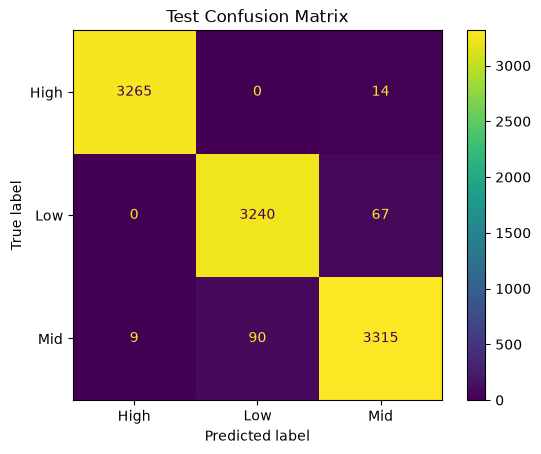

In [9]:
y_test_pred = model.predict(X_test1)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    values_format="d"
)

plt.title("Test Confusion Matrix")
plt.show()


## 8. Coefficients

In [10]:
# Binary: one coefficient per feature.
# Multinomial: one coefficient row per class.

if model.coef_.shape[0] == 1:
    coefficient_df = pd.DataFrame({
        "Feature": X_train1.columns,
        "Coefficient": model.coef_[0]
    })
    display(coefficient_df)

else:
    coefficient_df = pd.DataFrame(
        model.coef_,
        index=[f"Class={c}" for c in model.classes_],
        columns=X_train1.columns
    )
    display(coefficient_df)


,StudentID,SGPA_Sem1,SGPA_Sem2,SGPA_Sem3,SGPA_Sem4,SGPA_Sem5,SGPA_Sem6,SGPA_Sem7,SGPA_Sem8,CGPA,...,Stream_Civil,Stream_ECE,Stream_EE,Stream_IT,Stream_Mechanical,Specialisation_DataScience,Specialisation_Embedded,Specialisation_Networking,Hostel_Yes,HistoryOfBacklogs_Yes
Class=High,0.044470,2.811254,2.554027,2.826398,2.798170,2.834680,2.831508,2.774218,2.989610,2.217317,...,-0.010847,0.175553,0.201641,0.213314,0.080212,0.118284,0.046534,-0.002420,-0.066625,1.002281
Class=Low,-0.041270,-3.066434,-2.728619,-2.931559,-2.906695,-2.963038,-3.194560,-3.129029,-3.325714,-2.270420,...,-0.009684,-0.129508,-0.298109,-0.147999,0.044997,0.056845,0.105958,0.102998,0.010791,-0.784566
Class=Mid,-0.003199,0.255179,0.174593,0.105161,0.108524,0.128358,0.363052,0.354811,0.336105,0.053103,...,0.020530,-0.046045,0.096468,-0.065315,-0.125209,-0.175129,-0.152492,-0.100577,0.055834,-0.217715


## 9. Coefficient Bar Chart

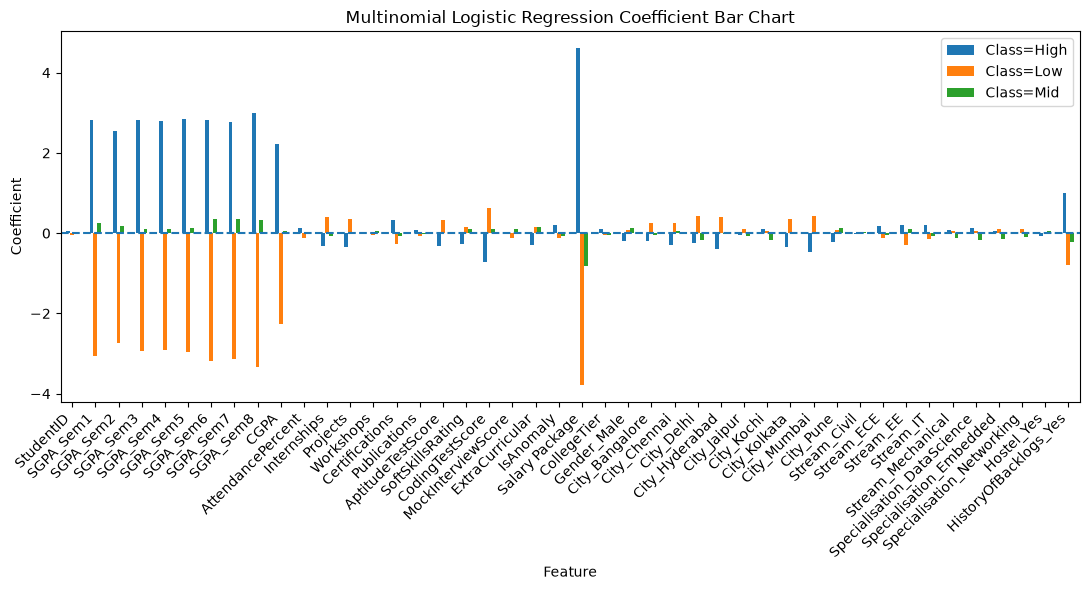

In [11]:
if model.coef_.shape[0] == 1:

    plot_df = pd.DataFrame({
        "Feature": X_train1.columns,
        "Coefficient": model.coef_[0]
    }).sort_values("Coefficient")

    plt.figure(figsize=(9, 6))
    plt.barh(plot_df["Feature"], plot_df["Coefficient"])
    plt.axvline(0, linestyle="--")
    plt.xlabel("Coefficient")
    plt.ylabel("Feature")
    plt.title("Logistic Regression Coefficient Bar Chart")
    plt.tight_layout()
    plt.show()

else:
    coefficient_plot_df = coefficient_df.T

    ax = coefficient_plot_df.plot(
        kind="bar",
        figsize=(11, 6)
    )

    ax.axhline(0, linestyle="--")
    ax.set_xlabel("Feature")
    ax.set_ylabel("Coefficient")
    ax.set_title("Multinomial Logistic Regression Coefficient Bar Chart")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


# Interpretation and Conclusion

### Target
This notebook predicts **`CGPA_Tier`**.

### Metrics
- Accuracy: overall percentage of correct predictions.
- Precision: correctness of positive predictions.
- Recall: ability to identify actual positive cases.
- F1-score: balance between precision and recall.
- ROC-AUC: used for the binary model to measure discrimination across thresholds.

### Coefficients
A positive coefficient increases the model's tendency toward the corresponding class; a negative coefficient decreases it, subject to the preprocessing and class formulation.

### Final evaluation
The **test-set metrics** are the final performance results because `X_test` and `y_test` are kept separate from model fitting.
